### Options Trading: Long & Short Straddle 

In [4]:
import pandas as pd
import numpy as np

import yfinance as yf

import plotly.express as px
import plotly.graph_objs as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import plotly.io as pio
from IPython.display import display
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

#### Annualized Volatility
Volatility plays a crucial role in options trading. It is a key input in options pricing models, such as the Black-Scholes model. Higher volatility increases the probability that the option will end up in the money, providing an advantageous deal for buying or selling the underlying asset on the expiration date. This increases the premium of options, allowing the trader to sell them at a higher price.



#### Annualized Volatility

In [5]:
def get_ticker(ticker):


    # Downloading historical data
    df = yf.download(ticker, period = '5y', interval = '1d')
    df.columns = df.columns.get_level_values(0) # Flattening multi-level columns

    # Computing returns
    df['Returns'] = df['Close'].pct_change()

    # Computing annualized volatility
    df['Vol'] = df['Returns'].rolling(20).std() * np.sqrt(252)
    df.dropna(axis = 0, inplace = True) # Removing null values

    # Generating array of equally-spaced points representing the quantiles to be calculated (from 0% to 100%)
    quantiles = np.quantile(df['Vol'], np.linspace(0,1,11))

    # Using quantilies to categorize and label the annualized volatility values
    quantile_labels = pd.cut(df['Vol'], bins = quantiles, 
                             labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    
    # Adding categorical labels to the dataframe
    df['Vol_Rank'] = quantile_labels

    # Plotting data
    fig = make_subplots(rows = 3, cols = 1, horizontal_spacing=0.2, row_heights=[.60, .20, .20], shared_xaxes=True)

    # First row --> Closing Price
    fig.add_trace(go.Scatter(
        x = df.index, y = df['Close'], name = 'Closing Price'
    ), row = 1, col = 1)

    # Second row --> Annualized Volatility
    fig.add_trace(go.Scatter(
        x = df.index, y = df['Vol'], name = 'Annualized Volatility'
    ), row = 2, col = 1)

    # Third row --> Volatility rank
    fig.add_trace(go.Scatter(
        x = df.index, y = df['Vol_Rank'], name = 'Volatility Rank'
    ), row = 3, col = 1)

    # Defining subplots layout
    fig.update_layout(title = {'text': f'<b>{ticker} Closing Price & Volatility</b>'},
                      template = 'plotly_white',
                      height = 900, width = 950,
                      showlegend=False,
                      hovermode='x unified')
    
    # Defining layout of y-axes across subplots
    fig.update_yaxes(title_text = 'Closing Price ($)', row = 1)
    fig.update_yaxes(title_text = 'Annualized Volatility', row = 2)
    fig.update_yaxes(title_text = 'Volatility Rank', row = 3)

    fig.show() # Displaying plot

In [ ]:
get_ticker('AAPL') 

# the result can not be showed on github, so I replace with the image below

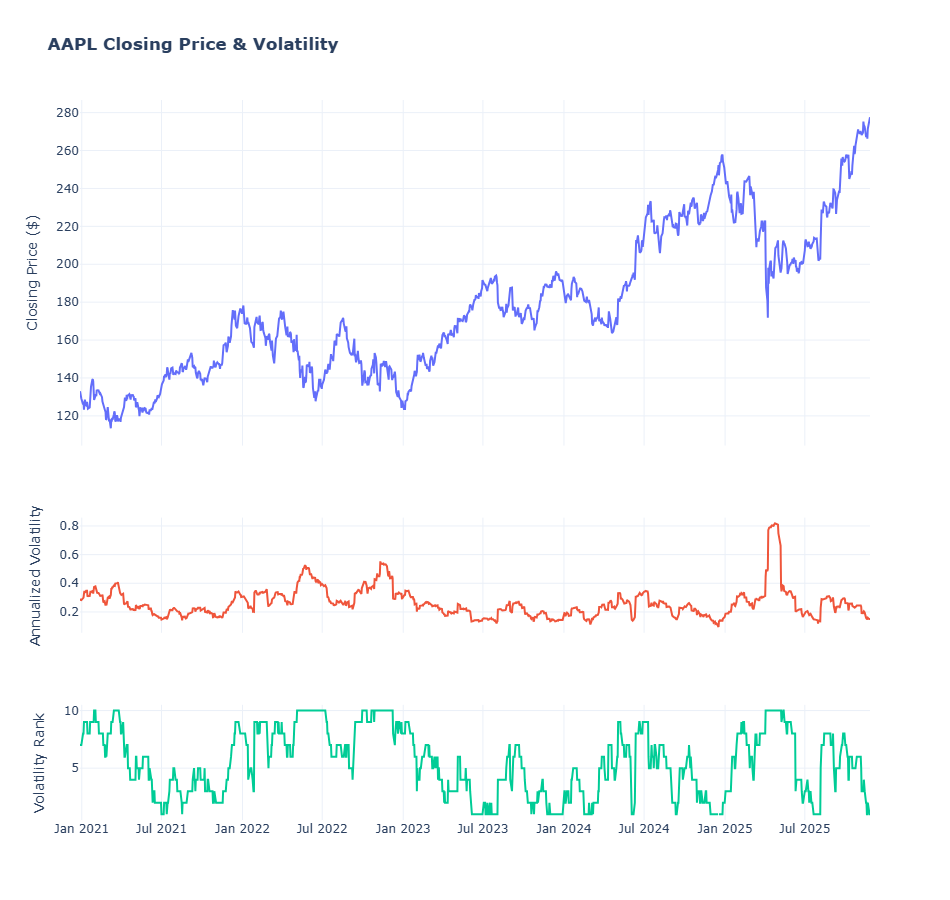

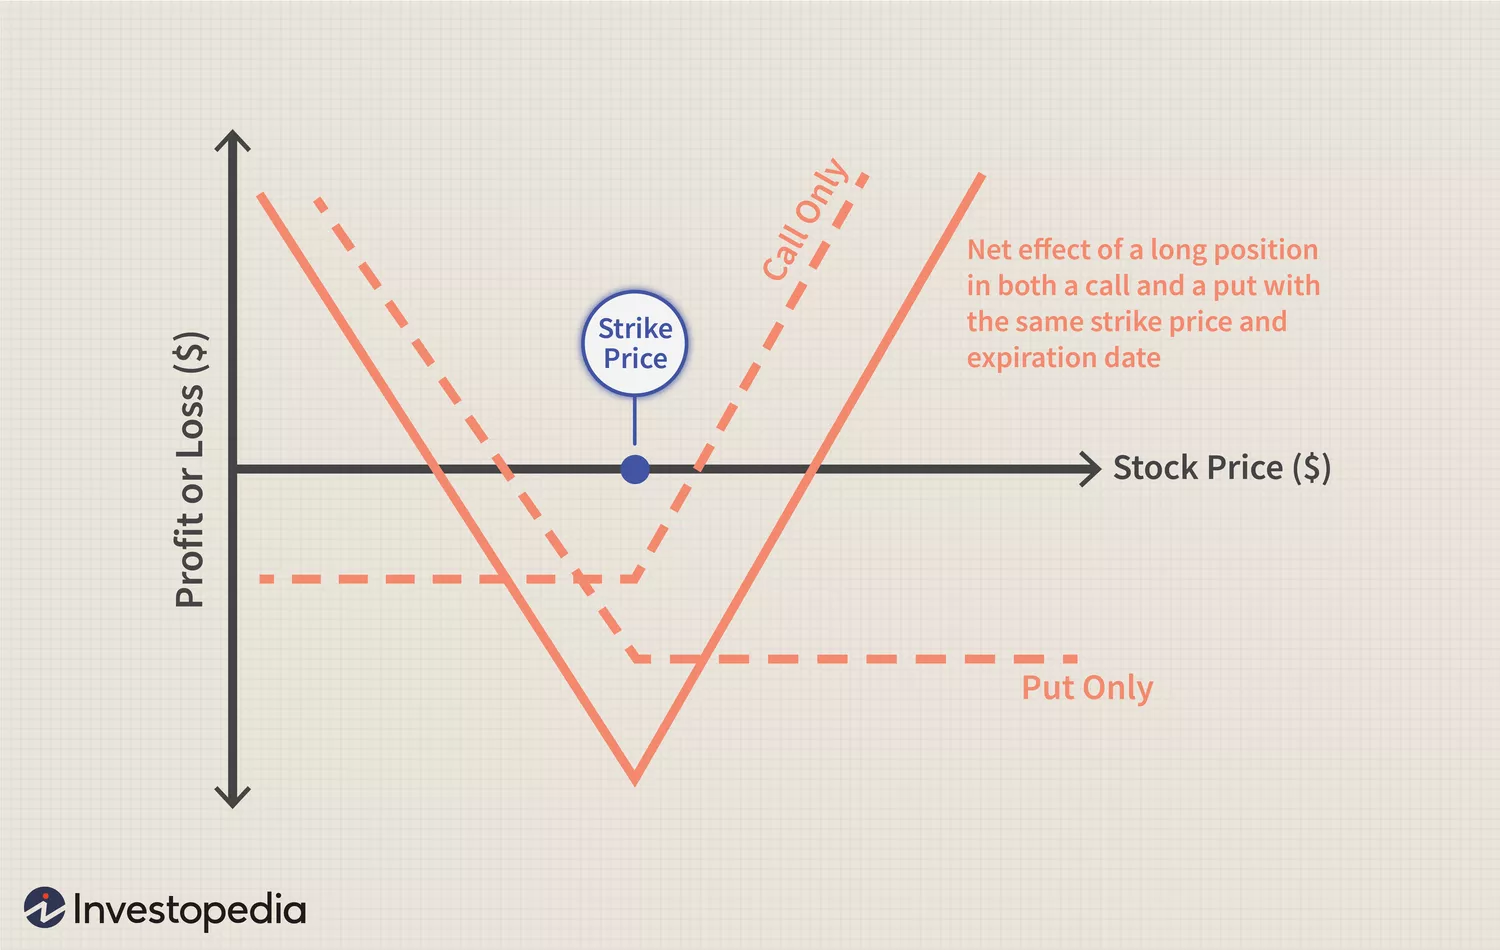 

In [7]:
def get_strategy(ticker, strike_call, strike_put, premium_call, premium_put):

    # Generating an array of possible prices the underlying asset might fall into
    stock_prices = np.linspace(0.79 * min(strike_put, strike_call), 1.19 * max(strike_put, strike_call), 100).round(2)

    # Computing payoffs
    # Payoffs for holding long call and put options 
    long_call_payoff = np.maximum(stock_prices - strike_call, 0) - premium_call
    long_put_payoff = np.maximum(strike_put - stock_prices, 0) - premium_put

    # Payoffs for holding short positions in call and put options
    short_call_payoff = -long_call_payoff
    short_put_payoff = -long_put_payoff

    # Combined payoffs for both long and short positions
    combined_long_payoff = long_call_payoff + long_put_payoff
    combined_short_payoff = short_call_payoff + short_put_payoff

    # Computing profit and loss for long straddle
    profit_long = np.maximum(combined_long_payoff, 0)
    loss_long = np.minimum(combined_long_payoff, 0)

    # Computing profit and loss for short straddle
    loss_short = np.minimum(combined_short_payoff, 0)
    profit_short = np.maximum(combined_short_payoff, 0)
    
    # Creating subplots
    fig = make_subplots(
        rows=2, cols=1,
        horizontal_spacing=0.2,
        row_heights=[0.5, 0.5],
        shared_xaxes=False,
        shared_yaxes=False
    )

    # Adding Long Straddle traces
    fig.add_trace(
        go.Scatter(x=stock_prices, y=long_call_payoff, mode='lines', line=dict(color='grey', dash='dash'), name='Long Call', hovertemplate='%{y:.2f}'),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=stock_prices, y=long_put_payoff, mode='lines', line=dict(color='grey', dash='dash'),  name='Long Put', hovertemplate='%{y:.2f}'),
        row=1, col=1
    )

    # Adding Short Straddle traces
    fig.add_trace(
        go.Scatter(x=stock_prices, y=short_call_payoff, mode='lines', line=dict(color='grey', dash='dash'),  name='Short Call', hovertemplate='%{y:.2f}'),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=stock_prices, y=short_put_payoff, mode='lines', line=dict(color='grey', dash='dash'), name='Short Put', hovertemplate='%{y:.2f}'),
        row=2, col=1
    )
    

    # Adding the payoff lines for Long Straddle
    fig.add_trace(
        go.Scatter(x=stock_prices, y=profit_long, mode='lines', line=dict(color='black', dash='solid'), name='Profit', hovertemplate='%{y:.2f}',
                    fill='tozeroy', fillcolor='rgba(0, 255, 0, 0.5)'),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=stock_prices, y=loss_long, mode='lines', line=dict(color='black', dash='solid'), name='Loss', hovertemplate='%{y:.2f}',
                    fill='tozeroy', fillcolor='rgba(255, 0, 0, 0.5)'),
        row=1, col=1
    )

    # Adding the payoff lines for Long Straddle
    fig.add_trace(
        go.Scatter(x=stock_prices, y=loss_short, mode='lines', line=dict(color='black', dash='solid'), name = 'Loss', hovertemplate='%{y:.2f}',
                   fill='tozeroy', fillcolor='rgba(255, 0, 0, 0.5)'),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=stock_prices, y=profit_short, mode='lines', line=dict(color='black', dash='solid'), name = 'Profit', hovertemplate='%{y:.2f}',
                   fill='tozeroy', fillcolor='rgba(0, 255, 0, 0.5)'),
        row=2, col=1
    )

    
    # Defining layout
    fig.update_layout(
        title={'text': f'<b>{ticker} Long & Short Straddle</b>'},
        template='plotly_white',
        height=1000, width=750,
        showlegend=False,
        hovermode='x unified')

    # Defining y-axes and x-axes tiles across rows
    fig.update_yaxes(title_text='Long Payoff ($)', row=1)
    fig.update_yaxes(title_text='Short Payoff ($)', row=2)
    fig.update_xaxes(title_text = 'Underlying Asset Price at Expiration', row=1)
    fig.update_xaxes(title_text = 'Underlying Asset Price at Expiration', row=2)

    fig.show()

In [8]:
# Using function to obtain long and short straddle payoffs
get_strategy('AAPL', 187.50, 187.50, 2.99, 3.70)

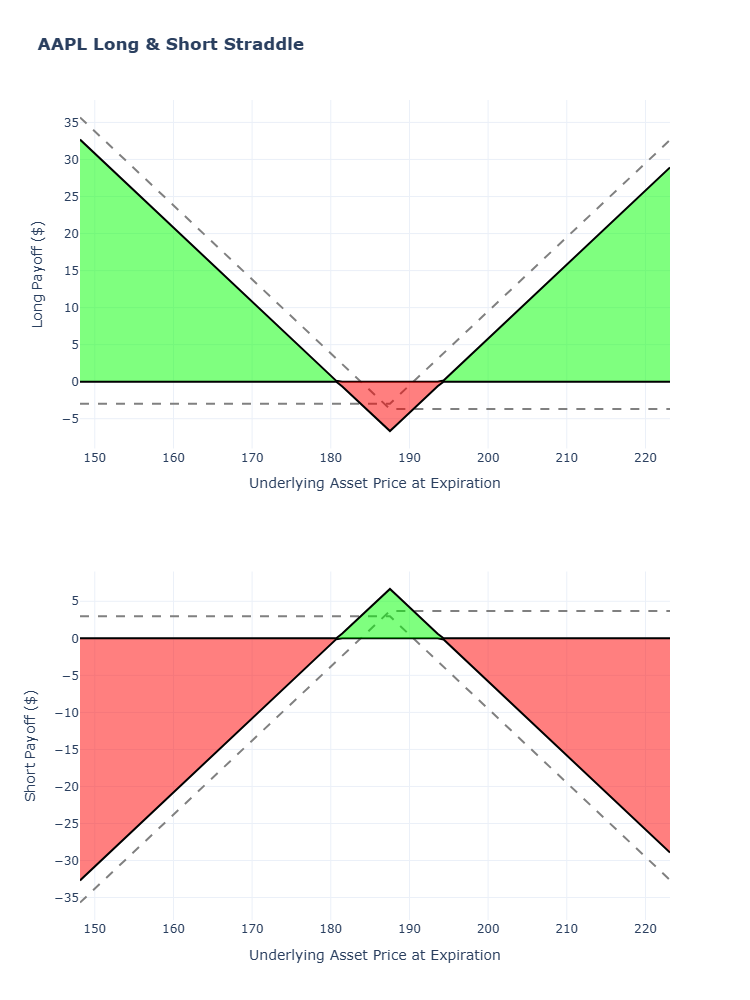